In [1]:
from __future__ import annotations
import argparse
import os
import sys
from pathlib import Path

# Make the repo root importable when running directly
_REPO = Path(__name__).resolve().parents[1]
print(_REPO)
sys.path.insert(0, str(_REPO))

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

import yaml
import tensorflow as tf

tf.keras.config.disable_traceback_filtering()

from gsn.datasets import load_tgb
from gsn.train.loop import GSNLinkPredictor, Trainer, TrainerConfig

/hdd_data/jay/arijit/GSN


In [2]:
def _load_yaml(path: str) -> dict:
    with open(path) as f:
        return yaml.safe_load(f)

In [3]:
config_path = "../configs/wikipedia.yaml"
raw = _load_yaml(config_path)

In [4]:
ckpt_path = "./checkpoints/tgbl-wiki/"

In [5]:
ds_cfg  = raw["dataset"]
mdl_cfg = raw["model"]
trn_cfg = raw["trainer"]

name = ds_cfg["name"]
root = ds_cfg.get("root", "data/")

tf.random.set_seed(raw["trainer"]["seed"])
tf.keras.utils.set_random_seed(raw["trainer"]["seed"])

print(f"Loading dataset '{name}' from '{root}' ...")
(train, val, test), meta = load_tgb(name, root = root)
num_nodes = meta["num_nodes"]
print(f"  {num_nodes} nodes | train {len(train)} | val {len(val)} | test {len(test)}")

Loading dataset 'tgbl-wiki' from 'data/' ...
  9227 nodes | train 110232 | val 23621 | test 23621


In [6]:
model = GSNLinkPredictor.from_pretrained(ckpt_path, edge_feat_dim = int(meta["edge_feat_dim"]))
table = model.state_tables[0].clone()

I0000 00:00:1778906753.463598  104520 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16624 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9



Loaded from checkpoints/tgbl-wiki/best.weights.h5


In [7]:
table = table.numpy()
table.shape

(9227, 2048)

<Axes: >

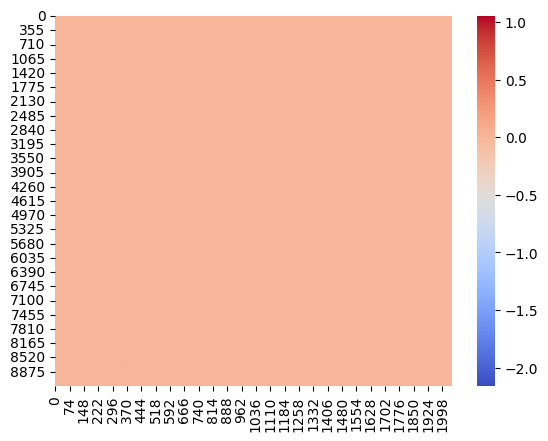

In [8]:
import seaborn as sns
sns.heatmap(table, cmap = "coolwarm")

In [13]:
weights = model.item_proj.get_weights()[0]
weights.shape

(192, 128)

<Axes: >

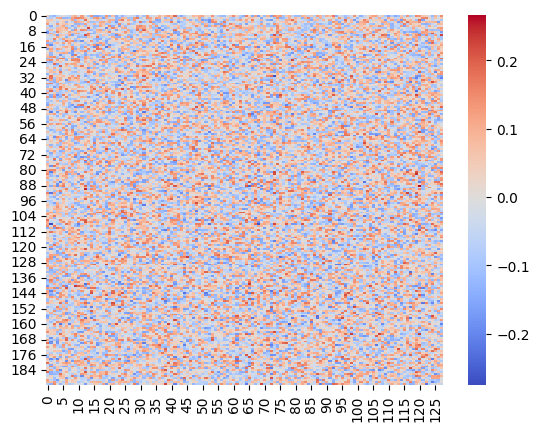

In [14]:
sns.heatmap(weights, cmap = "coolwarm")